In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

NUM_CLASSES = 20
IMAGE_EMBEDDING_DIM = 2048
TEXT_EMBEDDING_DIM = 768

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0
Device: mps


1. Build the Image Encoder

In [3]:
weights = models.ResNet50_Weights.DEFAULT

resnet = models.resnet50(
    weights=weights
)

resnet.fc = nn.Linear(
    IMAGE_EMBEDDING_DIM,
    NUM_CLASSES
)

resnet.load_state_dict(
    torch.load(
        "../models/resnet50_best.pth",
        map_location=device
    )
)

resnet = resnet.to(device)

In [4]:
image_encoder = nn.Sequential(
    *list(resnet.children())[:-1]
)

image_encoder = image_encoder.to(device)
image_encoder.eval()

print("Image encoder loaded.")

Image encoder loaded.


2. Verify Image Embedding

In [5]:
%run ./02_Data_Preparation.ipynb

Device: mps
Train: (29901, 6)
Validation: (6435, 6)
Test: (6459, 6)
../data/raw/fashion-product-images-small/images/15970.jpg
Exists: True
Image size: (60, 80)
Image mode: RGB
Image mode: RGB
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tenosr min: -2.0836544036865234
Tensor max: 2.640000104904175
Dataset size: 29901
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: tensor(17)
Label dtype: torch.int64
index 0: shape=torch.Size([3, 224, 224]), label=17
index 100: shape=torch.Size([3, 224, 224]), label=17
index 1000: shape=torch.Size([3, 224, 224]), label=13
index 5000: shape=torch.Size([3, 224, 224]), label=17
index 10000: shape=torch.Size([3, 224, 224]), label=0
Train datasets: 29901
Validation datasets: 6435
Test dataset: 6459
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Label dtype: torch.int64
Labels: tensor([17,  0, 17, 16,  6,  1,  7, 17, 17, 17, 19,  0, 13, 15, 19, 17, 17,  8,


Text: Turtle Check Men Navy Blue Shirt
Input IDs shape: torch.Size([1, 32])
Attention mask shape: torch.Size([1, 32])
['[CLS]', 'turtle', 'check', 'men', 'navy', 'blue', 'shirt', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])
Orignal : Turtle Check Men Navy Blue Shirt
Decoded : turtle check men navy blue shirt
Input IDs shape: torch.Size([8, 32])
Attention mask shape: torch.Size([8, 32])
Maximum token length:  30
Texts with > 32 tokens: 0
Multimodal train dataset: 29901
dict_keys(['image', 'input_ids', 'attention_mask', 'label'])
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Input IDs shape: torch.Size([32])
Input IDs dtype: torch.int64
Attention mask shape: torch.Size([32])
At

In [6]:
images, labels = next(
    iter(test_loader)
)

images = images.to(device)

with torch.no_grad():
    image_features = image_encoder(images)

image_features = torch.flatten(
    image_features,
    start_dim=1
)

print("Image features:", image_features.shape)

Image features: torch.Size([32, 2048])


3. Load the Trained Text Encoder

In [7]:
from transformers import AutoModel

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 32


class DistilBERTTextEncoder(nn.Module):

    def __init__(
        self,
        model_name="distilbert-base-uncased"
    ):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(
            model_name
        )

        self.hidden_size = (
            self.transformer.config.hidden_size
        )

    def masked_mean_pooling(
        self,
        last_hidden_state,
        attention_mask
    ):
        mask = attention_mask.unsqueeze(-1).expand(
            last_hidden_state.size()
        ).float()

        summed_embeddings = torch.sum(
            last_hidden_state * mask,
            dim=1
        )

        token_count = torch.clamp(
            mask.sum(dim=1),
            min=1e-9
        )

        return summed_embeddings / token_count

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_embedding = self.masked_mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        return text_embedding

In [8]:
class TextClassifier(nn.Module):

    def __init__(
        self,
        model_name="distilbert-base-uncased",
        num_classes=20
    ):
        super().__init__()

        self.text_encoder = DistilBERTTextEncoder(
            model_name
        )

        self.classifier = nn.Linear(
            self.text_encoder.hidden_size,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        text_embedding = self.text_encoder(
            input_ids,
            attention_mask
        )

        logits = self.classifier(
            text_embedding
        )

        return logits

In [9]:
text_classifier = TextClassifier(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES
)

text_classifier.load_state_dict(
    torch.load(
        "../models/distilbert_text_classifier_best.pth",
        map_location=device
    )
)

text_classifier = text_classifier.to(device)
text_classifier.eval()

print("Text model loaded.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text model loaded.


4. Extract the Text Encoder

In [10]:
text_encoder = text_classifier.text_encoder

text_encoder = text_encoder.to(device)
text_encoder.eval()

print(
    "Text embedding dimension:",
    text_encoder.hidden_size
)

Text embedding dimension: 768


In [11]:
batch = next(
    iter(multimodal_test_loader)
)

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

with torch.no_grad():

    text_features = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Text features:", text_features.shape)

Text features: torch.Size([32, 768])


5. Create the Multimodal Fusion Model

In [12]:
class MultimodalClassifier(nn.Module):

    def __init__(
        self,
        image_encoder,
        text_encoder,
        num_classes=20
    ):
        super().__init__()

        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        # Image projection
        self.image_projection = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU()
        )

        # Text projection
        self.text_projection = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU()
        )

        # Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(
        self,
        images,
        input_ids,
        attention_mask
    ):

        # Image features
        image_features = self.image_encoder(
            images
        )

        image_features = torch.flatten(
            image_features,
            start_dim=1
        )

        # Text features
        text_features = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Project both modalities
        image_features = self.image_projection(
            image_features
        )

        text_features = self.text_projection(
            text_features
        )

        # Concatenate
        fused_features = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Final classification
        logits = self.fusion(
            fused_features
        )

        return logits

6. Freeze Both Pretrained Encoder

In [13]:
for param in image_encoder.parameters():
    param.requires_grad = False

for param in text_encoder.parameters():
    param.requires_grad = False

7. Create the Multimodal Model

In [14]:
multimodal_model = MultimodalClassifier(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    num_classes=NUM_CLASSES
)

multimodal_model = multimodal_model.to(device)

print(multimodal_model)

MultimodalClassifier(
  (image_encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=Tru

In [15]:
total_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 91581268
Trainable parameters: 1710356


In [16]:
print("\nTrainable layers:")

for name, param in multimodal_model.named_parameters():

    if param.requires_grad:
        print(
            name,
            param.shape
        )


Trainable layers:
image_projection.0.weight torch.Size([512, 2048])
image_projection.0.bias torch.Size([512])
text_projection.0.weight torch.Size([512, 768])
text_projection.0.bias torch.Size([512])
fusion.0.weight torch.Size([256, 1024])
fusion.0.bias torch.Size([256])
fusion.3.weight torch.Size([20, 256])
fusion.3.bias torch.Size([20])


8. Test the Complete Multimodal Forward Pass

In [17]:
batch = next(
    iter(multimodal_test_loader)
)

images = batch["image"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["label"].to(device)

with torch.no_grad():

    logits = multimodal_model(
        images=images,
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Image shape:", images.shape)
print("Input IDs shape:", input_ids.shape)
print("Attention mask shape:", attention_mask.shape)
print("Labels shape:", labels.shape)
print("Logits shape:", logits.shape)

Image shape: torch.Size([32, 3, 224, 224])
Input IDs shape: torch.Size([32, 32])
Attention mask shape: torch.Size([32, 32])
Labels shape: torch.Size([32])
Logits shape: torch.Size([32, 20])


### Multimodal Architecture Design & Encoder Integration

- Integrated trained ResNet-50 image encoder
- Integrated trained DistilBERT text encoder
- Image representation: 2048 dimensions
- Text representation: 768 dimensions
- Image projection: 2048 → 512
- Text projection: 768 → 512
- Fused representation: 1024 dimensions
- Fusion layer: 1024 → 256
- Dropout: 0.3
- Classification layer: 256 → 20
- ResNet-50 backbone frozen
- DistilBERT backbone frozen
- Projection and fusion layers trainable
- Total parameters: 91,581,268
- Trainable parameters: 1,710,356
- Verified complete multimodal forward pass
- Final logits shape: [32, 20]

9. Cross-Entropy Loss

In [18]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [19]:
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        multimodal_model.parameters()
    ),
    lr=1e-3
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [20]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("Scheduler:", scheduler)

Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x1472a4c20>


In [21]:
optimizer_params = sum(
    p.numel()
    for group in optimizer.param_groups
    for p in group["params"]
)

print(
    "Parameters passed to optimizer:",
    optimizer_params
)

Parameters passed to optimizer: 1710356


10. Verify Frozen Parameters

In [22]:
trainable_backbone_params = []

for name, param in multimodal_model.named_parameters():

    if param.requires_grad and (
        name.startswith("image_encoder")
        or name.startswith("text_encoder")
    ):
        trainable_backbone_params.append(name)

print(
    "Trainable backbone parameters:",
    trainable_backbone_params
)

Trainable backbone parameters: []


11. Count Parameters by Component

In [23]:
component_params = {
    "image_encoder": sum(
        p.numel()
        for p in multimodal_model.image_encoder.parameters()
    ),
    "text_encoder": sum(
        p.numel()
        for p in multimodal_model.text_encoder.parameters()
    ),
    "image_projection": sum(
        p.numel()
        for p in multimodal_model.image_projection.parameters()
    ),
    "text_projection": sum(
        p.numel()
        for p in multimodal_model.text_projection.parameters()
    ),
    "fusion": sum(
        p.numel()
        for p in multimodal_model.fusion.parameters()
    )
}

for name, count in component_params.items():
    print(f"{name}: {count:,}")

image_encoder: 23,508,032
text_encoder: 66,362,880
image_projection: 1,049,088
text_projection: 393,728
fusion: 267,540


### Configure Multimodal Training

- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.001
- Scheduler: ReduceLROnPlateau
- ResNet-50 encoder: Frozen
- DistilBERT encoder: Frozen
- Image projection: Trainable
- Text projection: Trainable
- Fusion network: Trainable
- Parameters passed to optimizer: 1,710,356
- Verified no encoder parameters are trainable
- Verified component parameter counts

12. Training Function

In [24]:
def train_multimodal_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep the pretrained encoders frozen
    model.image_encoder.eval()
    model.text_encoder.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:

        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Calculate loss
        loss = criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update trainable projection/fusion layers
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * labels.size(0)
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

13. Validation Function

In [25]:
def validate_multimodal_one_epoch(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = logits.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
NUM_EPOCHS = 5

multimodal_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

14. Train the Fusion Model

In [27]:
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_multimodal_one_epoch(
        multimodal_model,
        multimodal_train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_multimodal_one_epoch(
        multimodal_model,
        multimodal_val_loader,
        criterion,
        device
    )

    # Update scheduler
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # Save history
    multimodal_history["train_loss"].append(
        train_loss
    )

    multimodal_history["train_accuracy"].append(
        train_accuracy
    )

    multimodal_history["val_loss"].append(
        val_loss
    )

    multimodal_history["val_accuracy"].append(
        val_accuracy
    )

    multimodal_history["learning_rate"].append(
        current_lr
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            multimodal_model.state_dict(),
            "../models/multimodal_best.pth"
        )

        print("  ✓ Best multimodal model saved")

Epoch [1/5] | Train Loss: 0.2860 | Train Acc: 0.9183 | Val Loss: 0.0737 | Val Acc: 0.9781 | LR: 0.001000
  ✓ Best multimodal model saved
Epoch [2/5] | Train Loss: 0.0671 | Train Acc: 0.9798 | Val Loss: 0.0446 | Val Acc: 0.9877 | LR: 0.001000
  ✓ Best multimodal model saved
Epoch [3/5] | Train Loss: 0.0465 | Train Acc: 0.9864 | Val Loss: 0.0599 | Val Acc: 0.9841 | LR: 0.001000
Epoch [4/5] | Train Loss: 0.0367 | Train Acc: 0.9888 | Val Loss: 0.0474 | Val Acc: 0.9879 | LR: 0.001000
Epoch [5/5] | Train Loss: 0.0327 | Train Acc: 0.9903 | Val Loss: 0.0431 | Val Acc: 0.9893 | LR: 0.001000
  ✓ Best multimodal model saved


15. Load the Best Multimodal Checkpoint

In [28]:
# Load the best multimodal model
best_model_path = "../models/multimodal_best.pth"

multimodal_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

multimodal_model = multimodal_model.to(device)
multimodal_model.eval()

print("Best multimodal model loaded")

Best multimodal model loaded


16. Create the Evaluation Function

In [29]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np


def evaluate_multimodal_model(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            predictions = logits.argmax(dim=1)

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    test_loss = running_loss / total

    test_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    return (
        test_loss,
        test_accuracy,
        macro_f1,
        weighted_f1,
        np.array(all_labels),
        np.array(all_predictions)
    )

17. Run Test Evaluation

In [30]:
(
    test_loss,
    test_accuracy,
    macro_f1,
    weighted_f1,
    y_true,
    y_pred
) = evaluate_multimodal_model(
    multimodal_model,
    multimodal_test_loader,
    criterion,
    device
)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Accuracy:   {test_accuracy:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Test Loss:       0.0320
Test Accuracy:   0.9921
Macro F1:        0.9776
Weighted F1:     0.9921


18. Classification Report

In [33]:
class_names = [
    name for name, label in sorted(
        label_mapping.items(),
        key=lambda x: x[1]
    )
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

                    Bags     0.9783    1.0000    0.9890       450
                   Belts     1.0000    1.0000    1.0000       128
              Bottomwear     0.9920    0.9816    0.9868       380
                   Dress     0.9800    0.9423    0.9608        52
                 Eyewear     1.0000    1.0000    1.0000       134
              Flip Flops     0.9645    0.9855    0.9749       138
               Fragrance     0.9937    1.0000    0.9968       157
               Innerwear     0.9962    0.9887    0.9924       265
               Jewellery     1.0000    0.9947    0.9973       188
                    Lips     0.9451    1.0000    0.9718        86
Loungewear and Nightwear     0.8814    0.9630    0.9204        54
                  Makeup     1.0000    0.8000    0.8889        35
                   Nails     0.9487    1.0000    0.9737        37
                  Sandal     0.9124    0.9690    0.9398       129
         

19. Confusion Matrix

In [34]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix Shape:", cm.shape)
print(cm)

Confusion Matrix Shape: (20, 20)
[[ 450    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0  128    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0  373    1    0    0    0    0    0    0    5    0    0    1
     0    0    0    0    0    0]
 [   0    0    0   49    0    0    0    0    0    0    0    0    0    0
     0    0    0    3    0    0]
 [   0    0    0    0  134    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0  136    0    0    0    0    0    0    0    2
     0    0    0    0    0    0]
 [   0    0    0    0    0    0  157    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    1    0    0    0    0  262    0    0    2    0    0    0
     0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0  187    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0 

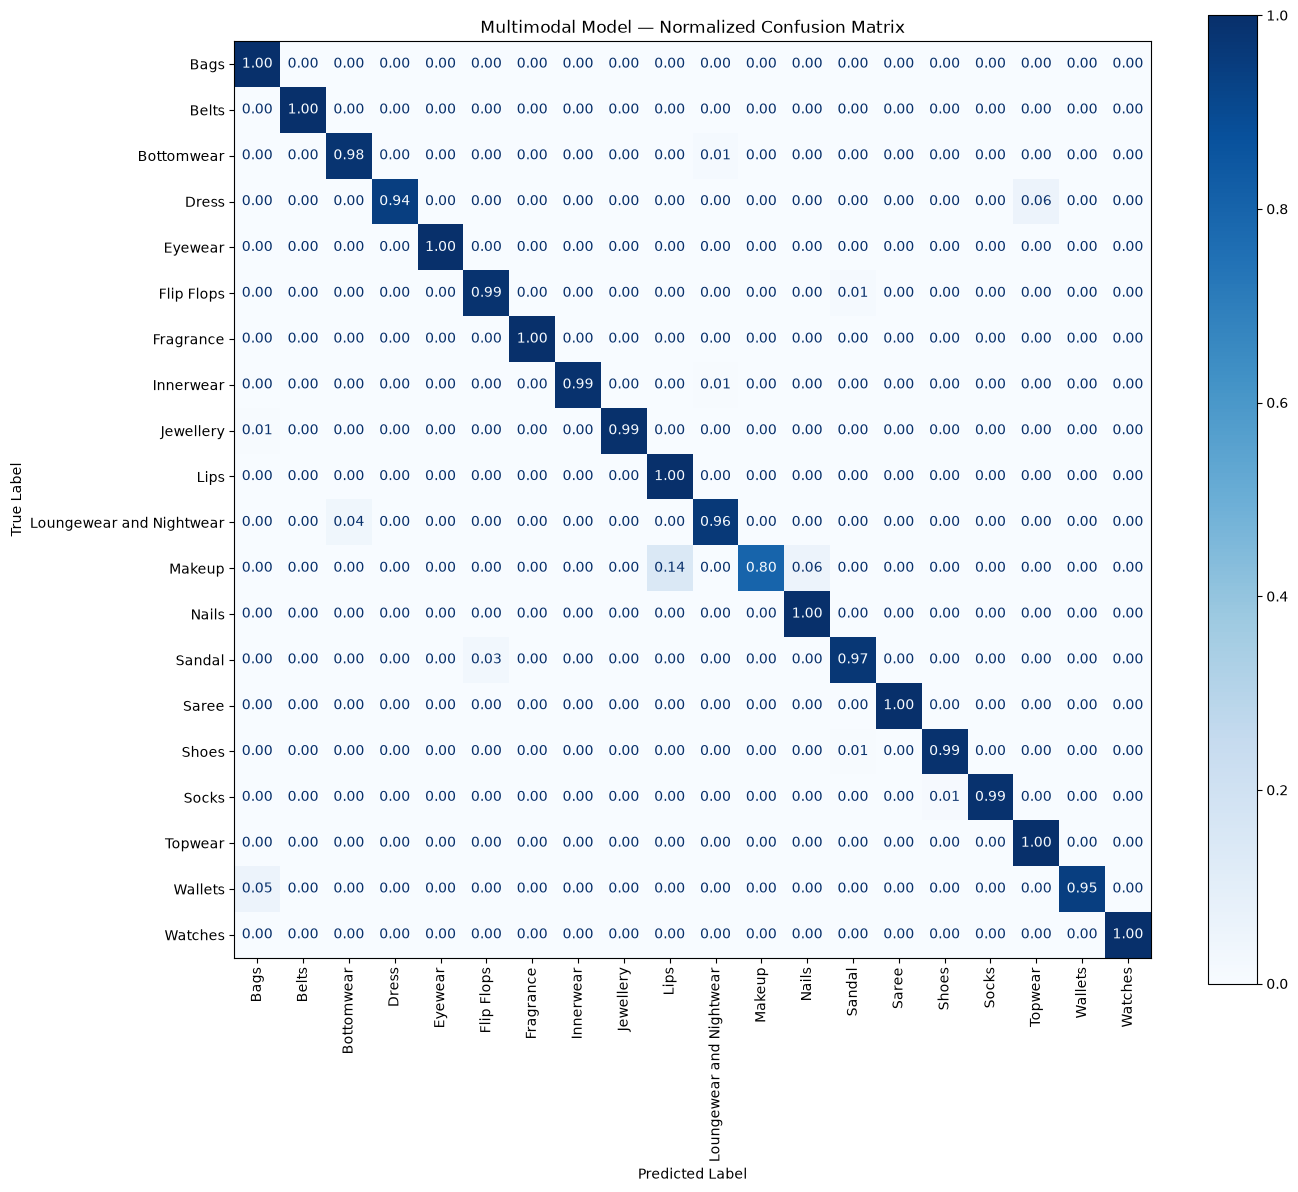

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Normalize each row by the number of true samples
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f"
)

ax.set_title("Multimodal Model — Normalized Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Multimodal Fusion Results

The multimodal classifier combines pretrained ResNet-50 image embeddings
(2048 dimensions) and DistilBERT text embeddings (768 dimensions) through
learnable projection and fusion layers.

#### Test Performance

- Test Loss: 0.0320
- Test Accuracy: 99.21%
- Macro F1: 97.76%
- Weighted F1: 99.21%

#### Comparison

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| Image-only (ResNet-50) | 94.04% | 86.40% | 93.84% |
| Text-only (DistilBERT) | 97.77% | 96.51% | 97.76% |
| Multimodal | 99.21% | 97.76% | 99.21% |

The multimodal model outperformed both individual modalities on the
held-out test set, demonstrating the benefit of combining visual and
textual product information.

20. Rebuild the Image Encoder

In [36]:
# Create a fresh ResNet-50 backbone
optimized_resnet = models.resnet50(
    weights=weights
)

# Replace the classification head with our 20-class head
optimized_resnet.fc = nn.Linear(
    optimized_resnet.fc.in_features,
    NUM_CLASSES
)

# Load the best image-only checkpoint
optimized_resnet.load_state_dict(
    torch.load(
        "../models/resnet50_best.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [37]:
optimized_image_encoder = nn.Sequential(
    *list(optimized_resnet.children())[:-1]
)

optimized_image_encoder = optimized_image_encoder.to(device)

21. reeze Everything First

In [38]:
for param in optimized_image_encoder.parameters():
    param.requires_grad = False

In [39]:
for param in optimized_image_encoder[7].parameters():
    param.requires_grad = True

22. Verify Trainable Parameters

In [41]:
total_params = sum(
    p.numel()
    for p in optimized_image_encoder.parameters()
)

trainable_params = sum(
    p.numel()
    for p in optimized_image_encoder.parameters()
    if p.requires_grad
)

print(f"Total image encoder parameters: {total_params:,}")
print(f"Trainable image encoder parameters: {trainable_params:,}")

Total image encoder parameters: 23,508,032
Trainable image encoder parameters: 14,964,736


In [42]:
for name, param in optimized_image_encoder.named_parameters():
    if param.requires_grad:
        print(name)

7.0.conv1.weight
7.0.bn1.weight
7.0.bn1.bias
7.0.conv2.weight
7.0.bn2.weight
7.0.bn2.bias
7.0.conv3.weight
7.0.bn3.weight
7.0.bn3.bias
7.0.downsample.0.weight
7.0.downsample.1.weight
7.0.downsample.1.bias
7.1.conv1.weight
7.1.bn1.weight
7.1.bn1.bias
7.1.conv2.weight
7.1.bn2.weight
7.1.bn2.bias
7.1.conv3.weight
7.1.bn3.weight
7.1.bn3.bias
7.2.conv1.weight
7.2.bn1.weight
7.2.bn1.bias
7.2.conv2.weight
7.2.bn2.weight
7.2.bn2.bias
7.2.conv3.weight
7.2.bn3.weight
7.2.bn3.bias


23. Keep DistilBERT Frozen

In [43]:
for param in multimodal_model.text_encoder.parameters():
    param.requires_grad = False

24. Create the Optimized Multimodal Model

In [44]:
class OptimizedMultimodalClassifier(nn.Module):

    def __init__(
        self,
        image_encoder,
        text_encoder,
        num_classes=20
    ):
        super().__init__()

        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        self.image_projection = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU()
        )

        self.text_projection = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU()
        )

        self.fusion = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(
        self,
        images,
        input_ids,
        attention_mask
    ):

        image_features = self.image_encoder(images)
        image_features = torch.flatten(
            image_features,
            start_dim=1
        )

        image_features = self.image_projection(
            image_features
        )

        text_features = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = self.text_projection(
            text_features
        )

        combined_features = torch.cat(
            [image_features, text_features],
            dim=1
        )

        logits = self.fusion(
            combined_features
        )

        return logits

In [45]:
optimized_multimodal_model = OptimizedMultimodalClassifier(
    image_encoder=optimized_image_encoder,
    text_encoder=multimodal_model.text_encoder,
    num_classes=NUM_CLASSES
)

optimized_multimodal_model = optimized_multimodal_model.to(device)

25. Verify the Architecture

In [46]:
print(optimized_multimodal_model)

OptimizedMultimodalClassifier(
  (image_encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(in

In [47]:
total_params = sum(
    p.numel()
    for p in optimized_multimodal_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in optimized_multimodal_model.parameters()
    if p.requires_grad
)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 91,581,268
Trainable parameters: 16,675,092


In [48]:
print("\nTrainable components:")

for name, param in optimized_multimodal_model.named_parameters():
    if param.requires_grad:
        print(name)


Trainable components:
image_encoder.7.0.conv1.weight
image_encoder.7.0.bn1.weight
image_encoder.7.0.bn1.bias
image_encoder.7.0.conv2.weight
image_encoder.7.0.bn2.weight
image_encoder.7.0.bn2.bias
image_encoder.7.0.conv3.weight
image_encoder.7.0.bn3.weight
image_encoder.7.0.bn3.bias
image_encoder.7.0.downsample.0.weight
image_encoder.7.0.downsample.1.weight
image_encoder.7.0.downsample.1.bias
image_encoder.7.1.conv1.weight
image_encoder.7.1.bn1.weight
image_encoder.7.1.bn1.bias
image_encoder.7.1.conv2.weight
image_encoder.7.1.bn2.weight
image_encoder.7.1.bn2.bias
image_encoder.7.1.conv3.weight
image_encoder.7.1.bn3.weight
image_encoder.7.1.bn3.bias
image_encoder.7.2.conv1.weight
image_encoder.7.2.bn1.weight
image_encoder.7.2.bn1.bias
image_encoder.7.2.conv2.weight
image_encoder.7.2.bn2.weight
image_encoder.7.2.bn2.bias
image_encoder.7.2.conv3.weight
image_encoder.7.2.bn3.weight
image_encoder.7.2.bn3.bias
image_projection.0.weight
image_projection.0.bias
text_projection.0.weight
text_pr

26. Load the Phase 5 Multimodal Weights

In [49]:
# Initialize optimized model from the best Phase 5 multimodal checkpoint

baseline_multimodal_path = "../models/multimodal_best.pth"

optimized_multimodal_model.load_state_dict(
    torch.load(
        baseline_multimodal_path,
        map_location=device
    )
)

optimized_multimodal_model = optimized_multimodal_model.to(device)

print("✓ Phase 5 multimodal weights loaded into optimized model")

✓ Phase 5 multimodal weights loaded into optimized model


27. Verify Trainable Parameters Again

In [50]:
trainable_params = sum(
    p.numel()
    for p in optimized_multimodal_model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 16,675,092


28. Set Encoder Modes

In [51]:
optimized_multimodal_model.train()

optimized_multimodal_model.image_encoder.eval()
optimized_multimodal_model.text_encoder.eval()

DistilBERTTextEncoder(
  (transformer): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplac

In [52]:
optimized_multimodal_model.train()

OptimizedMultimodalClassifier(
  (image_encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(in

29. Configure Differential Learning Rates

In [53]:
criterion_optimized = nn.CrossEntropyLoss()

optimizer_optimized = torch.optim.Adam(
    [
        {
            "params": optimized_multimodal_model.image_encoder[7].parameters(),
            "lr": 1e-5
        },
        {
            "params": optimized_multimodal_model.image_projection.parameters(),
            "lr": 1e-3
        },
        {
            "params": optimized_multimodal_model.text_projection.parameters(),
            "lr": 1e-3
        },
        {
            "params": optimized_multimodal_model.fusion.parameters(),
            "lr": 1e-3
        }
    ]
)

scheduler_optimized = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_optimized,
    mode="min",
    factor=0.1,
    patience=2
)

30. Verify Optimizer

In [54]:
for i, param_group in enumerate(optimizer_optimized.param_groups):

    group_params = sum(
        p.numel()
        for p in param_group["params"]
    )

    print(
        f"Parameter Group {i + 1}: "
        f"{group_params:,} parameters | "
        f"LR = {param_group['lr']}"
    )

Parameter Group 1: 14,964,736 parameters | LR = 1e-05
Parameter Group 2: 1,049,088 parameters | LR = 0.001
Parameter Group 3: 393,728 parameters | LR = 0.001
Parameter Group 4: 267,540 parameters | LR = 0.001


31. Optimized Training Loop

In [55]:
def train_optimized_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep pretrained encoders in evaluation mode
    model.image_encoder.eval()
    model.text_encoder.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:

        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

32. Validation Loop

In [56]:
def validate_optimized_one_epoch(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = logits.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

33. Train for 5 Epochs

In [57]:
NUM_EPOCHS_OPTIMIZED = 5

optimized_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "layer4_lr": [],
    "fusion_lr": []
}

In [58]:
best_optimized_val_loss = float("inf")

for epoch in range(NUM_EPOCHS_OPTIMIZED):

    train_loss, train_accuracy = train_optimized_one_epoch(
        optimized_multimodal_model,
        multimodal_train_loader,
        criterion_optimized,
        optimizer_optimized,
        device
    )

    val_loss, val_accuracy = validate_optimized_one_epoch(
        optimized_multimodal_model,
        multimodal_val_loader,
        criterion_optimized,
        device
    )

    scheduler_optimized.step(val_loss)

    layer4_lr = optimizer_optimized.param_groups[0]["lr"]
    fusion_lr = optimizer_optimized.param_groups[1]["lr"]

    optimized_history["train_loss"].append(train_loss)
    optimized_history["train_accuracy"].append(train_accuracy)
    optimized_history["val_loss"].append(val_loss)
    optimized_history["val_accuracy"].append(val_accuracy)
    optimized_history["layer4_lr"].append(layer4_lr)
    optimized_history["fusion_lr"].append(fusion_lr)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS_OPTIMIZED}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Layer4 LR: {layer4_lr:.6f} | "
        f"Fusion LR: {fusion_lr:.6f}"
    )

    if val_loss < best_optimized_val_loss:

        best_optimized_val_loss = val_loss

        torch.save(
            optimized_multimodal_model.state_dict(),
            "../models/multimodal_optimized_best.pth"
        )

        print("  ✓ Best optimized multimodal model saved")

Epoch [1/5] | Train Loss: 0.0315 | Train Acc: 0.9906 | Val Loss: 0.0314 | Val Acc: 0.9936 | Layer4 LR: 0.000010 | Fusion LR: 0.001000
  ✓ Best optimized multimodal model saved
Epoch [2/5] | Train Loss: 0.0225 | Train Acc: 0.9931 | Val Loss: 0.0417 | Val Acc: 0.9897 | Layer4 LR: 0.000010 | Fusion LR: 0.001000
Epoch [3/5] | Train Loss: 0.0204 | Train Acc: 0.9934 | Val Loss: 0.0438 | Val Acc: 0.9913 | Layer4 LR: 0.000010 | Fusion LR: 0.001000
Epoch [4/5] | Train Loss: 0.0183 | Train Acc: 0.9946 | Val Loss: 0.0384 | Val Acc: 0.9927 | Layer4 LR: 0.000001 | Fusion LR: 0.000100
Epoch [5/5] | Train Loss: 0.0062 | Train Acc: 0.9982 | Val Loss: 0.0305 | Val Acc: 0.9941 | Layer4 LR: 0.000001 | Fusion LR: 0.000100
  ✓ Best optimized multimodal model saved


34. Load the Best Optimized Checkpoint

In [59]:
optimized_best_path = "../models/multimodal_optimized_best.pth"

optimized_multimodal_model.load_state_dict(
    torch.load(
        optimized_best_path,
        map_location=device
    )
)

optimized_multimodal_model = optimized_multimodal_model.to(device)
optimized_multimodal_model.eval()

print("✓ Best optimized multimodal model loaded")

✓ Best optimized multimodal model loaded


35. Evaluate on the Test Set

In [60]:
(
    optimized_test_loss,
    optimized_test_accuracy,
    optimized_macro_f1,
    optimized_weighted_f1,
    optimized_y_true,
    optimized_y_pred
) = evaluate_multimodal_model(
    optimized_multimodal_model,
    multimodal_test_loader,
    criterion_optimized,
    device
)

print(f"Optimized Test Loss:       {optimized_test_loss:.4f}")
print(f"Optimized Test Accuracy:   {optimized_test_accuracy:.4f}")
print(f"Optimized Macro F1:        {optimized_macro_f1:.4f}")
print(f"Optimized Weighted F1:     {optimized_weighted_f1:.4f}")

Optimized Test Loss:       0.0202
Optimized Test Accuracy:   0.9958
Optimized Macro F1:        0.9895
Optimized Weighted F1:     0.9958


36. Classification Report

In [61]:
print(
    classification_report(
        optimized_y_true,
        optimized_y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

                    Bags     0.9912    1.0000    0.9956       450
                   Belts     1.0000    1.0000    1.0000       128
              Bottomwear     0.9895    0.9895    0.9895       380
                   Dress     0.9615    0.9615    0.9615        52
                 Eyewear     1.0000    1.0000    1.0000       134
              Flip Flops     0.9852    0.9638    0.9744       138
               Fragrance     0.9874    1.0000    0.9937       157
               Innerwear     0.9962    1.0000    0.9981       265
               Jewellery     1.0000    1.0000    1.0000       188
                    Lips     1.0000    1.0000    1.0000        86
Loungewear and Nightwear     0.9615    0.9259    0.9434        54
                  Makeup     1.0000    0.9714    0.9855        35
                   Nails     1.0000    1.0000    1.0000        37
                  Sandal     0.9474    0.9767    0.9618       129
         

37. Confusion Matrix

In [64]:
optimized_cm = confusion_matrix(
    optimized_y_true,
    optimized_y_pred
)

print("Optimized Confusion Matrix Shape:", optimized_cm.shape)
print(optimized_cm)

Optimized Confusion Matrix Shape: (20, 20)
[[ 450    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0  128    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0  376    0    0    0    0    0    0    0    2    0    0    1
     0    0    0    1    0    0]
 [   0    0    1   50    0    0    0    0    0    0    0    0    0    0
     0    0    0    1    0    0]
 [   0    0    0    0  134    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0  133    0    0    0    0    0    0    0    5
     0    0    0    0    0    0]
 [   0    0    0    0    0    0  157    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0    0    0  265    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0  188    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0 

38. Direct Baseline vs Optimized Comparison

In [62]:
comparison = {
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Phase 5 Baseline": [
        test_loss,
        test_accuracy,
        macro_f1,
        weighted_f1
    ],
    "Phase 6 Optimized": [
        optimized_test_loss,
        optimized_test_accuracy,
        optimized_macro_f1,
        optimized_weighted_f1
    ]
}

comparison

{'Metric': ['Test Loss', 'Test Accuracy', 'Macro F1', 'Weighted F1'],
 'Phase 5 Baseline': [0.03202945077684028,
  0.9921040408732001,
  0.9775891567652426,
  0.9921060846068678],
 'Phase 6 Optimized': [0.020190792336470954,
  0.9958197863446354,
  0.9894504437523702,
  0.9958143424858124]}

In [63]:
print(
    f"Accuracy change: "
    f"{(optimized_test_accuracy - test_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Macro F1 change: "
    f"{(optimized_macro_f1 - macro_f1) * 100:+.2f} percentage points"
)

print(
    f"Weighted F1 change: "
    f"{(optimized_weighted_f1 - weighted_f1) * 100:+.2f} percentage points"
)

Accuracy change: +0.37 percentage points
Macro F1 change: +1.19 percentage points
Weighted F1 change: +0.37 percentage points


### Multimodal Optimization Results

Selective fine-tuning was applied to the final ResNet-50 block while keeping
the DistilBERT encoder frozen.

Differential learning rates were used:

- ResNet-50 Layer 4: 1e-5
- Projection/Fusion layers: 1e-3

The best optimized model was selected using validation loss and evaluated
once on the held-out test set.

### Final Optimized Performance

- Test Loss: 0.0202
- Test Accuracy: 99.58%
- Macro F1: 98.95%
- Weighted F1: 99.58%

### Baseline vs Optimized

| Metric | Baseline | Optimized | Improvement |
|--------|----------|-----------|-------------|
| Test Loss | 0.0320 | 0.0202 | -0.0118 |
| Test Accuracy | 99.21% | 99.58% | +0.37 pp |
| Macro F1 | 97.76% | 98.95% | +1.19 pp |
| Weighted F1 | 99.21% | 99.58% | +0.37 pp |

The optimized model was selected as the final multimodal model because
selective fine-tuning improved performance on the held-out test set.

In [65]:
import shutil

source_model = "../models/multimodal_optimized_best.pth"
final_model = "../models/multimodal_final.pth"

shutil.copy2(
    source_model,
    final_model
)

print(f"✓ Final multimodal model saved: {final_model}")

✓ Final multimodal model saved: ../models/multimodal_final.pth


39. Save Final Configuration

In [66]:
import json

final_config = {
    "model_name": "Multimodal Product Intelligence System",
    "num_classes": 20,
    "image_encoder": "ResNet-50",
    "image_embedding_dim": 2048,
    "image_projection_dim": 512,
    "text_encoder": "distilbert-base-uncased",
    "text_embedding_dim": 768,
    "text_projection_dim": 512,
    "fusion_input_dim": 1024,
    "fusion_hidden_dim": 256,
    "dropout": 0.3,
    "fine_tuned_image_block": "ResNet-50 Layer 4",
    "text_encoder_frozen": True,
    "image_layer4_learning_rate": 1e-5,
    "fusion_learning_rate": 1e-3,
    "final_test_accuracy": 0.9958197863446354,
    "final_macro_f1": 0.9894504437523702,
    "final_weighted_f1": 0.9958143424858124
}

with open("../models/multimodal_final_config.json", "w") as f:
    json.dump(final_config, f, indent=4)

print("✓ Final model configuration saved")

✓ Final model configuration saved


##  Explainability & Model Interpretation

40. Load the Final Model

In [118]:
final_model_path = "../models/multimodal_final.pth"

optimized_multimodal_model.load_state_dict(
    torch.load(
        final_model_path,
        map_location=device
    )
)

optimized_multimodal_model = optimized_multimodal_model.to(device)
optimized_multimodal_model.eval()

print("✓ Final multimodal model loaded")

✓ Final multimodal model loaded


41. Create a Single-Sample Prediction Function

In [119]:
def predict_multimodal_sample(
    model,
    batch,
    class_names,
    device
):
    model.eval()

    image = batch["image"][0].unsqueeze(0).to(device)
    input_ids = batch["input_ids"][0].unsqueeze(0).to(device)
    attention_mask = batch["attention_mask"][0].unsqueeze(0).to(device)
    label = batch["label"][0].item()

    with torch.no_grad():

        logits = model(
            images=image,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = class_names[prediction.item()]
    true_class = class_names[label]

    return {
        "predicted_class": predicted_class,
        "true_class": true_class,
        "confidence": confidence.item(),
        "probabilities": probabilities[0].cpu().numpy()
    }

42. Get a Test Sample

In [120]:
test_batch = next(iter(multimodal_test_loader))

prediction_result = predict_multimodal_sample(
    optimized_multimodal_model,
    test_batch,
    class_names,
    device
)

print(
    f"True Class:      {prediction_result['true_class']}"
)

print(
    f"Predicted Class: {prediction_result['predicted_class']}"
)

print(
    f"Confidence:      "
    f"{prediction_result['confidence']:.4f}"
)

True Class:      Bottomwear
Predicted Class: Bottomwear
Confidence:      1.0000


43. Display Top-5 Predictions

In [121]:
probabilities = prediction_result["probabilities"]

top_k = 5

top_indices = np.argsort(
    probabilities
)[::-1][:top_k]

print("Top-5 Predictions:\n")

for rank, idx in enumerate(top_indices, start=1):

    print(
        f"{rank}. "
        f"{class_names[idx]:30s} "
        f"{probabilities[idx]:.4f}"
    )

Top-5 Predictions:

1. Bottomwear                     1.0000
2. Topwear                        0.0000
3. Loungewear and Nightwear       0.0000
4. Dress                          0.0000
5. Bags                           0.0000


44. Display the Product Image

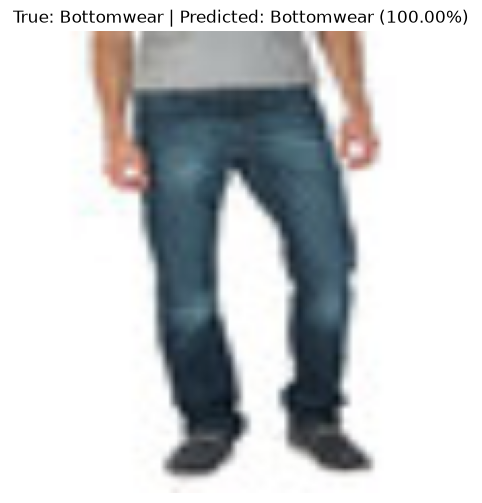

In [122]:
import matplotlib.pyplot as plt

image_tensor = test_batch["image"][0].cpu()

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

image_display = (
    image_tensor * std + mean
).clamp(0, 1)

image_display = image_display.permute(
    1, 2, 0
).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image_display)
plt.axis("off")

plt.title(
    f"True: {prediction_result['true_class']} | "
    f"Predicted: {prediction_result['predicted_class']} "
    f"({prediction_result['confidence']:.2%})"
)

plt.show()

45. Prepare the Final Model for Grad-CAM

In [123]:
optimized_multimodal_model.eval()

for param in optimized_multimodal_model.image_encoder.parameters():
    param.requires_grad = True

print("✓ Gradients enabled for image encoder")

✓ Gradients enabled for image encoder


46. Select the Target Layer

In [124]:
target_layer = (
    optimized_multimodal_model
    .image_encoder[7][2]
    .conv3
)

print(target_layer)

Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)


47. Create Forward and Backward Hooks

In [125]:
activations = None
gradients = None


def forward_hook(module, input, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

print("✓ Grad-CAM hooks registered")

✓ Grad-CAM hooks registered


48. Run One Sample Through the Model

In [126]:
image = test_batch["image"][0].unsqueeze(0).to(device)

input_ids = (
    test_batch["input_ids"][0]
    .unsqueeze(0)
    .to(device)
)

attention_mask = (
    test_batch["attention_mask"][0]
    .unsqueeze(0)
    .to(device)
)

label = test_batch["label"][0].item()

optimized_multimodal_model.zero_grad()

logits = optimized_multimodal_model(
    images=image,
    input_ids=input_ids,
    attention_mask=attention_mask
)

prediction = logits.argmax(dim=1)

print(
    "Predicted class:",
    class_names[prediction.item()]
)

Predicted class: Bottomwear


49. Backpropagate the Predicted Class

In [127]:
target_score = logits[
    0,
    prediction.item()
]

target_score.backward()

print("✓ Backward pass completed")

✓ Backward pass completed


In [128]:
print(
    "Activations shape:",
    activations.shape
)

print(
    "Gradients shape:",
    gradients.shape
)

Activations shape: torch.Size([1, 2048, 7, 7])
Gradients shape: torch.Size([1, 2048, 7, 7])


50. Generate the Grad-CAM Heatmap

In [129]:
activation = activations[0]
gradient = gradients[0]

weights = gradient.mean(
    dim=(1, 2)
)

cam = torch.sum(
    weights[:, None, None] * activation,
    dim=0
)

cam = torch.relu(cam)

cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

cam = cam.detach().cpu().numpy()

print("Grad-CAM shape:", cam.shape)
print(
    "Grad-CAM range:",
    cam.min(),
    "to",
    cam.max()
)

Grad-CAM shape: (7, 7)
Grad-CAM range: 0.0 to 1.0


51. Resize the Heatmap

In [130]:
from PIL import Image

heatmap = Image.fromarray(
    np.uint8(cam * 255)
)

heatmap = heatmap.resize(
    (224, 224),
    Image.Resampling.BILINEAR
)

heatmap = np.array(heatmap) / 255.0

print("Resized heatmap shape:", heatmap.shape)

Resized heatmap shape: (224, 224)


52. Visualize Grad-CAM

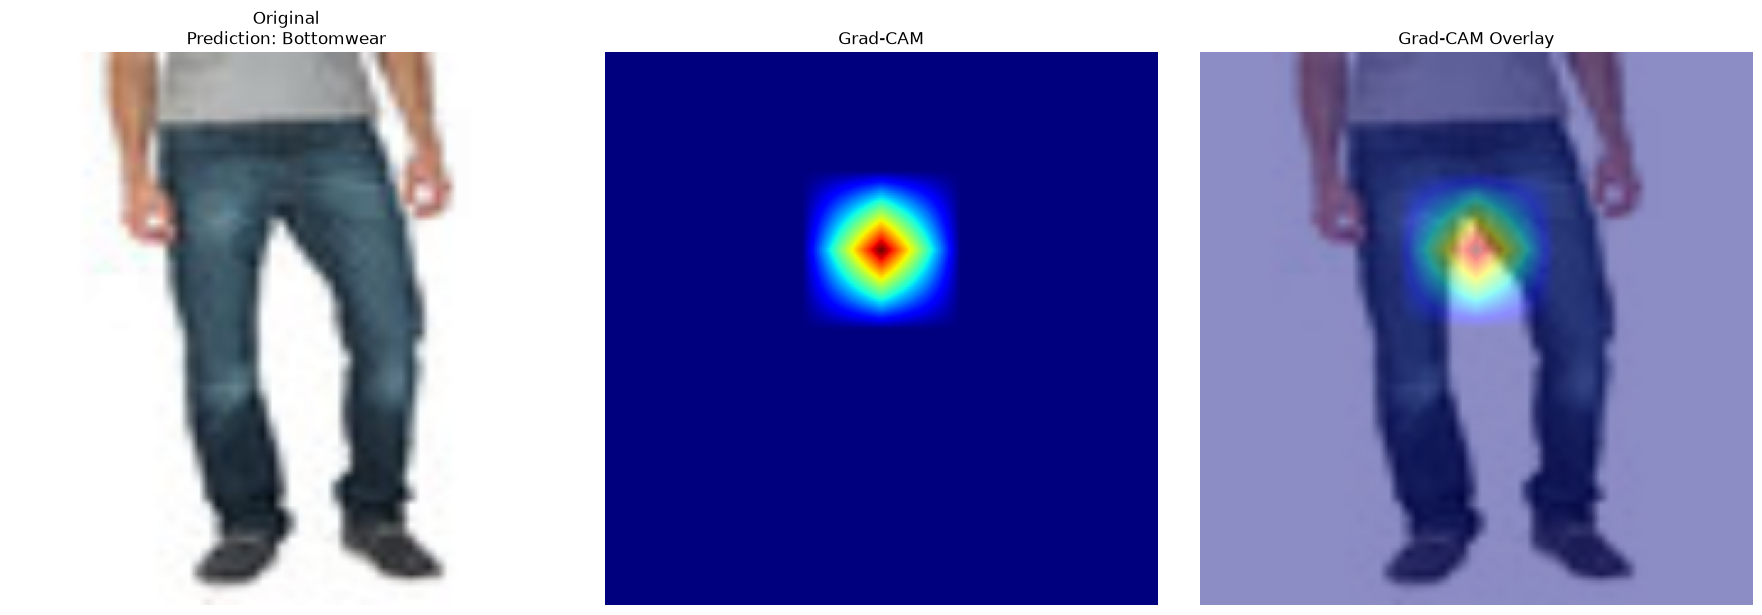

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_display)
plt.axis("off")
plt.title(
    f"Original\n"
    f"Prediction: {class_names[prediction.item()]}"
)

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.axis("off")
plt.title("Grad-CAM")

plt.subplot(1, 3, 3)
plt.imshow(image_display)
plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)
plt.axis("off")
plt.title("Grad-CAM Overlay")

plt.tight_layout()
plt.show()

In [132]:
forward_handle.remove()
backward_handle.remove()

print("✓ Grad-CAM hooks removed")

✓ Grad-CAM hooks removed


### Text Explainability

53. Get the Product Text

In [133]:
test_df = pd.read_csv(
    "../data/processed/test.csv"
)

test_sample = test_df.iloc[0]

print("True Class:", test_sample["subCategory"])
print("Product Name:", test_sample["productDisplayName"])

True Class: Bottomwear
Product Name: Peter England Men Party Blue Jeans


In [134]:
sample_index = test_batch["label"][0].item()

print("True Class:", class_names[sample_index])

test_sample = test_df.iloc[0]

print("Product Name:", test_sample["productDisplayName"])

True Class: Bottomwear
Product Name: Peter England Men Party Blue Jeans


54. Inspect DistilBERT Tokens

In [135]:
product_text = test_sample["productDisplayName"]

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

encoded = tokenizer(
    product_text,
    max_length=32,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

tokens = tokenizer.convert_ids_to_tokens(
    encoded["input_ids"][0]
)

print("Product Text:")
print(product_text)

print("\nTokens:")
print(tokens)

Product Text:
Peter England Men Party Blue Jeans

Tokens:
['[CLS]', 'peter', 'england', 'men', 'party', 'blue', 'jeans', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


55. Create a Gradient-Based Token Attribution Function

In [136]:
def get_text_token_attributions(
    model,
    input_ids,
    attention_mask,
    predicted_class
):
    model.eval()

    text_encoder = model.text_encoder

    embedding_layer = text_encoder.model.embeddings

    embeddings = embedding_layer(
        input_ids
    )

    embeddings = embeddings.detach()
    embeddings.requires_grad_(True)

    model.zero_grad()

    transformer_output = text_encoder.model.transformer(
        x=embeddings,
        attn_mask=attention_mask
    )

    last_hidden_state = transformer_output.last_hidden_state

    mask = attention_mask.unsqueeze(-1).float()

    pooled = (
        last_hidden_state * mask
    ).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

    text_features = text_encoder.projection(
        pooled
    ) if hasattr(text_encoder, "projection") else pooled

    return embeddings

In [137]:
print(optimized_multimodal_model.text_encoder)

DistilBERTTextEncoder(
  (transformer): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplac

56. Capture Token Embeddings and Gradients

In [138]:
optimized_multimodal_model.eval()

for param in optimized_multimodal_model.text_encoder.parameters():
    param.requires_grad = True

token_embeddings = None
token_embedding_gradients = None


def text_embedding_forward_hook(module, inputs, output):
    global token_embeddings

    token_embeddings = output
    token_embeddings.retain_grad()


embedding_layer = (
    optimized_multimodal_model
    .text_encoder
    .transformer
    .embeddings
    .word_embeddings
)

embedding_handle = embedding_layer.register_forward_hook(
    text_embedding_forward_hook
)

print("✓ Text embedding hook registered")

✓ Text embedding hook registered


57. Run the Complete Multimodal Prediction

In [139]:
image = test_batch["image"][0].unsqueeze(0).to(device)

input_ids = (
    test_batch["input_ids"][0]
    .unsqueeze(0)
    .to(device)
)

attention_mask = (
    test_batch["attention_mask"][0]
    .unsqueeze(0)
    .to(device)
)

label = test_batch["label"][0].item()

optimized_multimodal_model.zero_grad()

logits = optimized_multimodal_model(
    images=image,
    input_ids=input_ids,
    attention_mask=attention_mask
)

prediction = logits.argmax(dim=1)

print("True class:", class_names[label])
print("Predicted class:", class_names[prediction.item()])

True class: Bottomwear
Predicted class: Bottomwear


58. Backpropagate the Predicted Class

In [140]:
target_score = logits[
    0,
    prediction.item()
]

target_score.backward()

print("✓ Backward pass completed")

✓ Backward pass completed


In [141]:
print(
    "Token embeddings shape:",
    token_embeddings.shape
)

print(
    "Token embedding gradients shape:",
    token_embeddings.grad.shape
)

Token embeddings shape: torch.Size([1, 32, 768])
Token embedding gradients shape: torch.Size([1, 32, 768])


59. Calculate Token Importance

In [142]:
embeddings = token_embeddings[0]
gradients = token_embeddings.grad[0]

token_attributions = (
    embeddings * gradients
).sum(dim=1)

token_importance = token_attributions.abs()

token_importance = token_importance.detach().cpu().numpy()

print("Token importance shape:", token_importance.shape)

Token importance shape: (32,)


60. Convert Token IDs to Tokens

In [143]:
tokens = tokenizer.convert_ids_to_tokens(
    input_ids[0].detach().cpu().tolist()
)

print("Tokens and importance:\n")

for token, importance in zip(
    tokens,
    token_importance
):
    print(
        f"{token:20s} {importance:.6f}"
    )

Tokens and importance:

[CLS]                0.243773
peter                1.344389
england              0.264709
men                  1.114428
party                0.867764
blue                 0.069632
jeans                0.300428
[SEP]                0.774166
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000
[PAD]                0.000000


61. Remove Special Tokens and Padding

In [144]:
token_importance_pairs = []

for token, importance, mask_value in zip(
    tokens,
    token_importance,
    attention_mask[0].detach().cpu().numpy()
):

    if mask_value == 0:
        continue

    if token in ["[CLS]", "[SEP]", "[PAD]"]:
        continue

    token_importance_pairs.append(
        (token, float(importance))
    )

print("Meaningful tokens:\n")

for token, importance in token_importance_pairs:
    print(
        f"{token:20s} {importance:.6f}"
    )

Meaningful tokens:

peter                1.344389
england              0.264709
men                  1.114428
party                0.867764
blue                 0.069632
jeans                0.300428


62. Normalize Token Importance

In [145]:
importance_values = np.array(
    [importance for _, importance in token_importance_pairs]
)

if importance_values.max() > 0:
    normalized_importance = (
        importance_values / importance_values.max()
    )
else:
    normalized_importance = importance_values

normalized_token_importance = [
    (token, score)
    for (token, _), score in zip(
        token_importance_pairs,
        normalized_importance
    )
]

print("Normalized token importance:\n")

for token, score in normalized_token_importance:
    print(
        f"{token:20s} {score:.4f}"
    )

Normalized token importance:

peter                1.0000
england              0.1969
men                  0.8289
party                0.6455
blue                 0.0518
jeans                0.2235


63. Visualize Token Importance

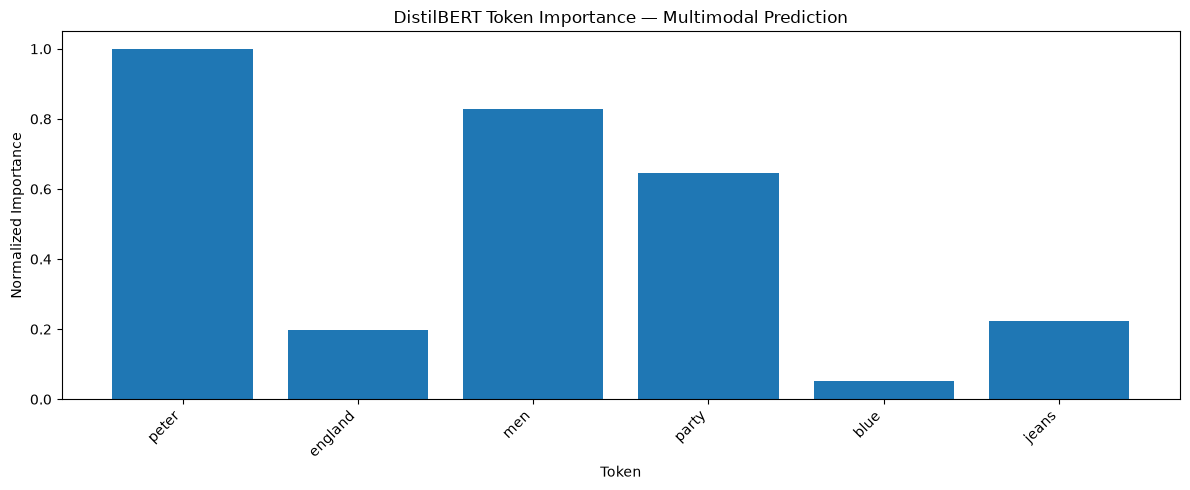

In [146]:
tokens_plot = [
    token
    for token, _ in normalized_token_importance
]

scores_plot = [
    score
    for _, score in normalized_token_importance
]

plt.figure(figsize=(12, 5))

plt.bar(
    range(len(tokens_plot)),
    scores_plot
)

plt.xticks(
    range(len(tokens_plot)),
    tokens_plot,
    rotation=45,
    ha="right"
)

plt.ylabel("Normalized Importance")
plt.xlabel("Token")

plt.title(
    "DistilBERT Token Importance — Multimodal Prediction"
)

plt.tight_layout()
plt.show()

64. Remove the Hook

In [147]:
embedding_handle.remove()

print("✓ Text embedding hook removed")

✓ Text embedding hook removed


In [148]:
for param in optimized_multimodal_model.text_encoder.parameters():
    param.requires_grad = False

print("✓ Text encoder frozen again")

✓ Text encoder frozen again


### Combined Multimodal Explanation

65. Create a Combined Explanation Figure

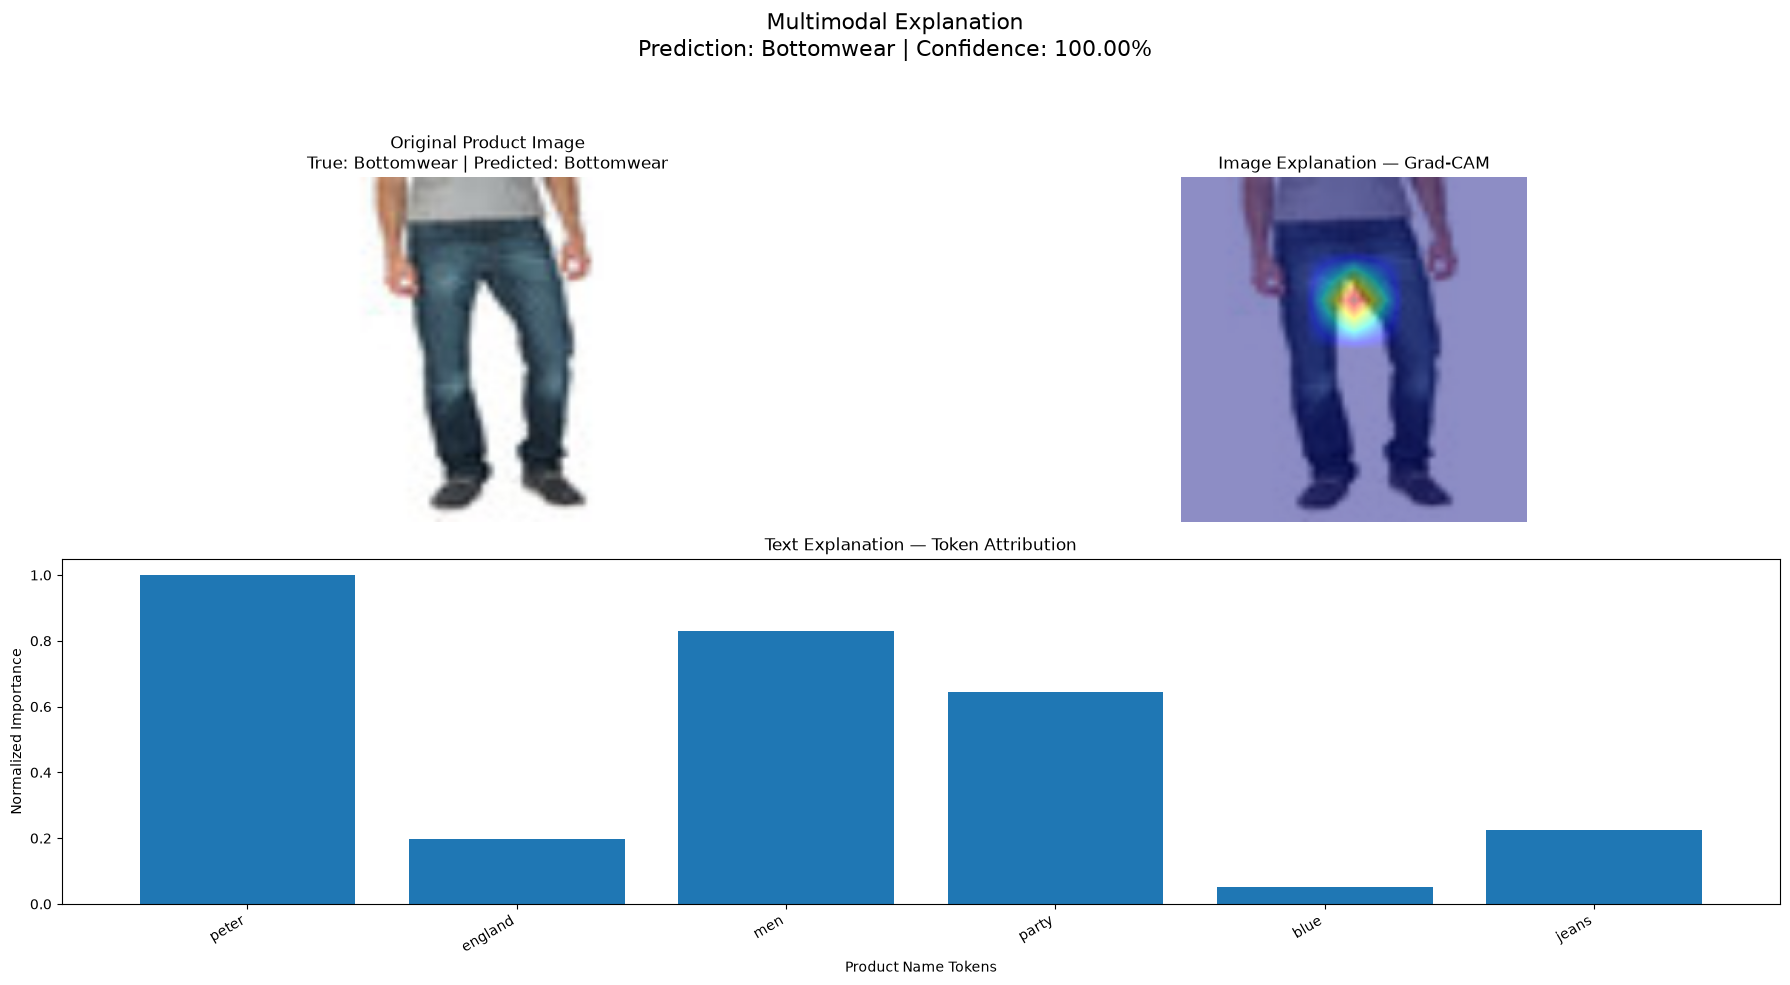

In [149]:
fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(2, 2, 1)

ax1.imshow(image_display)
ax1.axis("off")

ax1.set_title(
    f"Original Product Image\n"
    f"True: {class_names[label]} | "
    f"Predicted: {class_names[prediction.item()]}"
)

ax2 = plt.subplot(2, 2, 2)

ax2.imshow(image_display)
ax2.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)

ax2.axis("off")

ax2.set_title(
    "Image Explanation — Grad-CAM"
)

ax3 = plt.subplot(2, 1, 2)

ax3.bar(
    range(len(tokens_plot)),
    scores_plot
)

ax3.set_xticks(
    range(len(tokens_plot))
)

ax3.set_xticklabels(
    tokens_plot,
    rotation=30,
    ha="right"
)

ax3.set_ylabel(
    "Normalized Importance"
)

ax3.set_xlabel(
    "Product Name Tokens"
)

ax3.set_title(
    "Text Explanation — Token Attribution"
)

plt.suptitle(
    f"Multimodal Explanation\n"
    f"Prediction: {class_names[prediction.item()]} | "
    f"Confidence: "
    f"{prediction_result['confidence']:.2%}",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)
plt.show()

#### Multimodal Explanation

For the selected test sample:

- True class: Bottomwear
- Predicted class: Bottomwear
- Prediction confidence: 100%

##### Image Explanation

Grad-CAM was generated from the final convolutional layer of the
fine-tuned ResNet-50 image encoder. The strongest activation was
concentrated around the product's lower-body clothing region.

##### Text Explanation

Gradient × embedding attribution was used to estimate the relative
importance of the product-name tokens for the final multimodal
prediction.

The highest normalized attribution values for this sample were associated
with:

- peter
- men
- party

while `jeans` had a lower attribution value.

These attribution values represent local model sensitivity rather than
causal explanations and should therefore be interpreted as model
interpretation signals rather than definitive reasoning.

### Explainability Validation Across Multiple Samples

66. Select 5 Correctly Classified Samples

In [150]:
samples_for_explanation = []

for batch in multimodal_test_loader:

    images = batch["image"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    with torch.no_grad():
        logits = optimized_multimodal_model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = logits.argmax(dim=1)

    for i in range(len(labels)):

        if predictions[i].item() == labels[i].item():

            samples_for_explanation.append({
                "batch": batch,
                "index": i,
                "true_class": class_names[labels[i].item()],
                "predicted_class": class_names[predictions[i].item()]
            })

            if len(samples_for_explanation) >= 5:
                break

    if len(samples_for_explanation) >= 5:
        break

print(f"Collected {len(samples_for_explanation)} correctly classified samples.")

for i, sample in enumerate(samples_for_explanation, start=1):
    print(
        f"{i}. {sample['true_class']} "
        f"→ {sample['predicted_class']}"
    )

Collected 5 correctly classified samples.
1. Bottomwear → Bottomwear
2. Topwear → Topwear
3. Innerwear → Innerwear
4. Sandal → Sandal
5. Bottomwear → Bottomwear


67. Select 5 Diverse Correct Predictions

In [151]:
samples_for_explanation = []
selected_classes = set()

for batch in multimodal_test_loader:

    images = batch["image"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    with torch.no_grad():

        logits = optimized_multimodal_model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = logits.argmax(dim=1)

    for i in range(len(labels)):

        true_class = class_names[labels[i].item()]
        predicted_class = class_names[predictions[i].item()]

        # Correct prediction + new class
        if (
            true_class == predicted_class
            and true_class not in selected_classes
        ):

            samples_for_explanation.append({
                "batch": batch,
                "index": i,
                "true_class": true_class,
                "predicted_class": predicted_class
            })

            selected_classes.add(true_class)

            if len(samples_for_explanation) >= 5:
                break

    if len(samples_for_explanation) >= 5:
        break


print(
    f"Collected {len(samples_for_explanation)} "
    f"correctly classified samples."
)

for i, sample in enumerate(
    samples_for_explanation,
    start=1
):
    print(
        f"{i}. "
        f"{sample['true_class']} → "
        f"{sample['predicted_class']}"
    )

Collected 5 correctly classified samples.
1. Bottomwear → Bottomwear
2. Topwear → Topwear
3. Innerwear → Innerwear
4. Sandal → Sandal
5. Watches → Watches


68. Create a Reusable Explainability Function

In [152]:
def generate_multimodal_explanation(
    model,
    batch,
    index,
    tokenizer,
    class_names,
    device
):
    model.eval()

    image = (
        batch["image"][index]
        .unsqueeze(0)
        .to(device)
    )

    input_ids = (
        batch["input_ids"][index]
        .unsqueeze(0)
        .to(device)
    )

    attention_mask = (
        batch["attention_mask"][index]
        .unsqueeze(0)
        .to(device)
    )

    label = batch["label"][index].item()

    model.zero_grad()

    logits = model(
        images=image,
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    prediction = logits.argmax(dim=1)

    confidence = probabilities[
        0,
        prediction.item()
    ].item()

    activations = None
    gradients = None

    target_layer = (
        model.image_encoder[7][2].conv3
    )

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output
        activations.retain_grad()

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    model.zero_grad()

    logits = model(
        images=image,
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    target_score = logits[
        0,
        prediction.item()
    ]

    target_score.backward()

    activation = activations[0]
    gradient = gradients[0]

    weights = gradient.mean(
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * activation,
        dim=0
    )

    cam = torch.relu(cam)

    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    cam = cam.detach().cpu().numpy()

    heatmap = Image.fromarray(
        np.uint8(cam * 255)
    )

    heatmap = heatmap.resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    heatmap = np.array(
        heatmap
    ) / 255.0

    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()

    model.zero_grad()

    token_embeddings = None

    embedding_layer = (
        model
        .text_encoder
        .transformer
        .embeddings
        .word_embeddings
    )

    def text_forward_hook(module, input, output):
        nonlocal token_embeddings
        token_embeddings = output
        token_embeddings.retain_grad()

    embedding_handle = (
        embedding_layer.register_forward_hook(
            text_forward_hook
        )
    )

    logits = model(
        images=image,
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    target_score = logits[
        0,
        prediction.item()
    ]

    target_score.backward()

    embeddings = token_embeddings[0]
    token_gradients = token_embeddings.grad[0]

    token_attributions = (
        embeddings * token_gradients
    ).sum(dim=1)

    token_importance = (
        token_attributions
        .abs()
        .detach()
        .cpu()
        .numpy()
    )

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids[0]
        .detach()
        .cpu()
        .tolist()
    )

    token_importance_pairs = []

    mask_values = (
        attention_mask[0]
        .detach()
        .cpu()
        .numpy()
    )

    for token, importance, mask_value in zip(
        tokens,
        token_importance,
        mask_values
    ):

        if mask_value == 0:
            continue

        if token in [
            "[CLS]",
            "[SEP]",
            "[PAD]"
        ]:
            continue

        token_importance_pairs.append(
            (token, float(importance))
        )

    values = np.array([
        importance
        for _, importance
        in token_importance_pairs
    ])

    if values.max() > 0:
        values = values / values.max()

    normalized_token_importance = [
        (token, score)
        for (token, _), score
        in zip(
            token_importance_pairs,
            values
        )
    ]

    embedding_handle.remove()

    return {
        "true_class": class_names[label],
        "predicted_class": class_names[
            prediction.item()
        ],
        "confidence": confidence,
        "heatmap": heatmap,
        "token_importance": normalized_token_importance
    }

69. Generate Explanations for All 5 Samples

In [153]:
for param in optimized_multimodal_model.text_encoder.parameters():
    param.requires_grad = True

In [154]:
explanations = []

for sample in samples_for_explanation:

    explanation = generate_multimodal_explanation(
        optimized_multimodal_model,
        sample["batch"],
        sample["index"],
        tokenizer,
        class_names,
        device
    )

    explanations.append(explanation)

    print(
        f"{explanation['true_class']} → "
        f"{explanation['predicted_class']} | "
        f"Confidence: "
        f"{explanation['confidence']:.2%}"
    )

Bottomwear → Bottomwear | Confidence: 100.00%
Topwear → Topwear | Confidence: 100.00%
Innerwear → Innerwear | Confidence: 100.00%
Sandal → Sandal | Confidence: 99.95%
Watches → Watches | Confidence: 100.00%


70. Visualize the Five Explanations

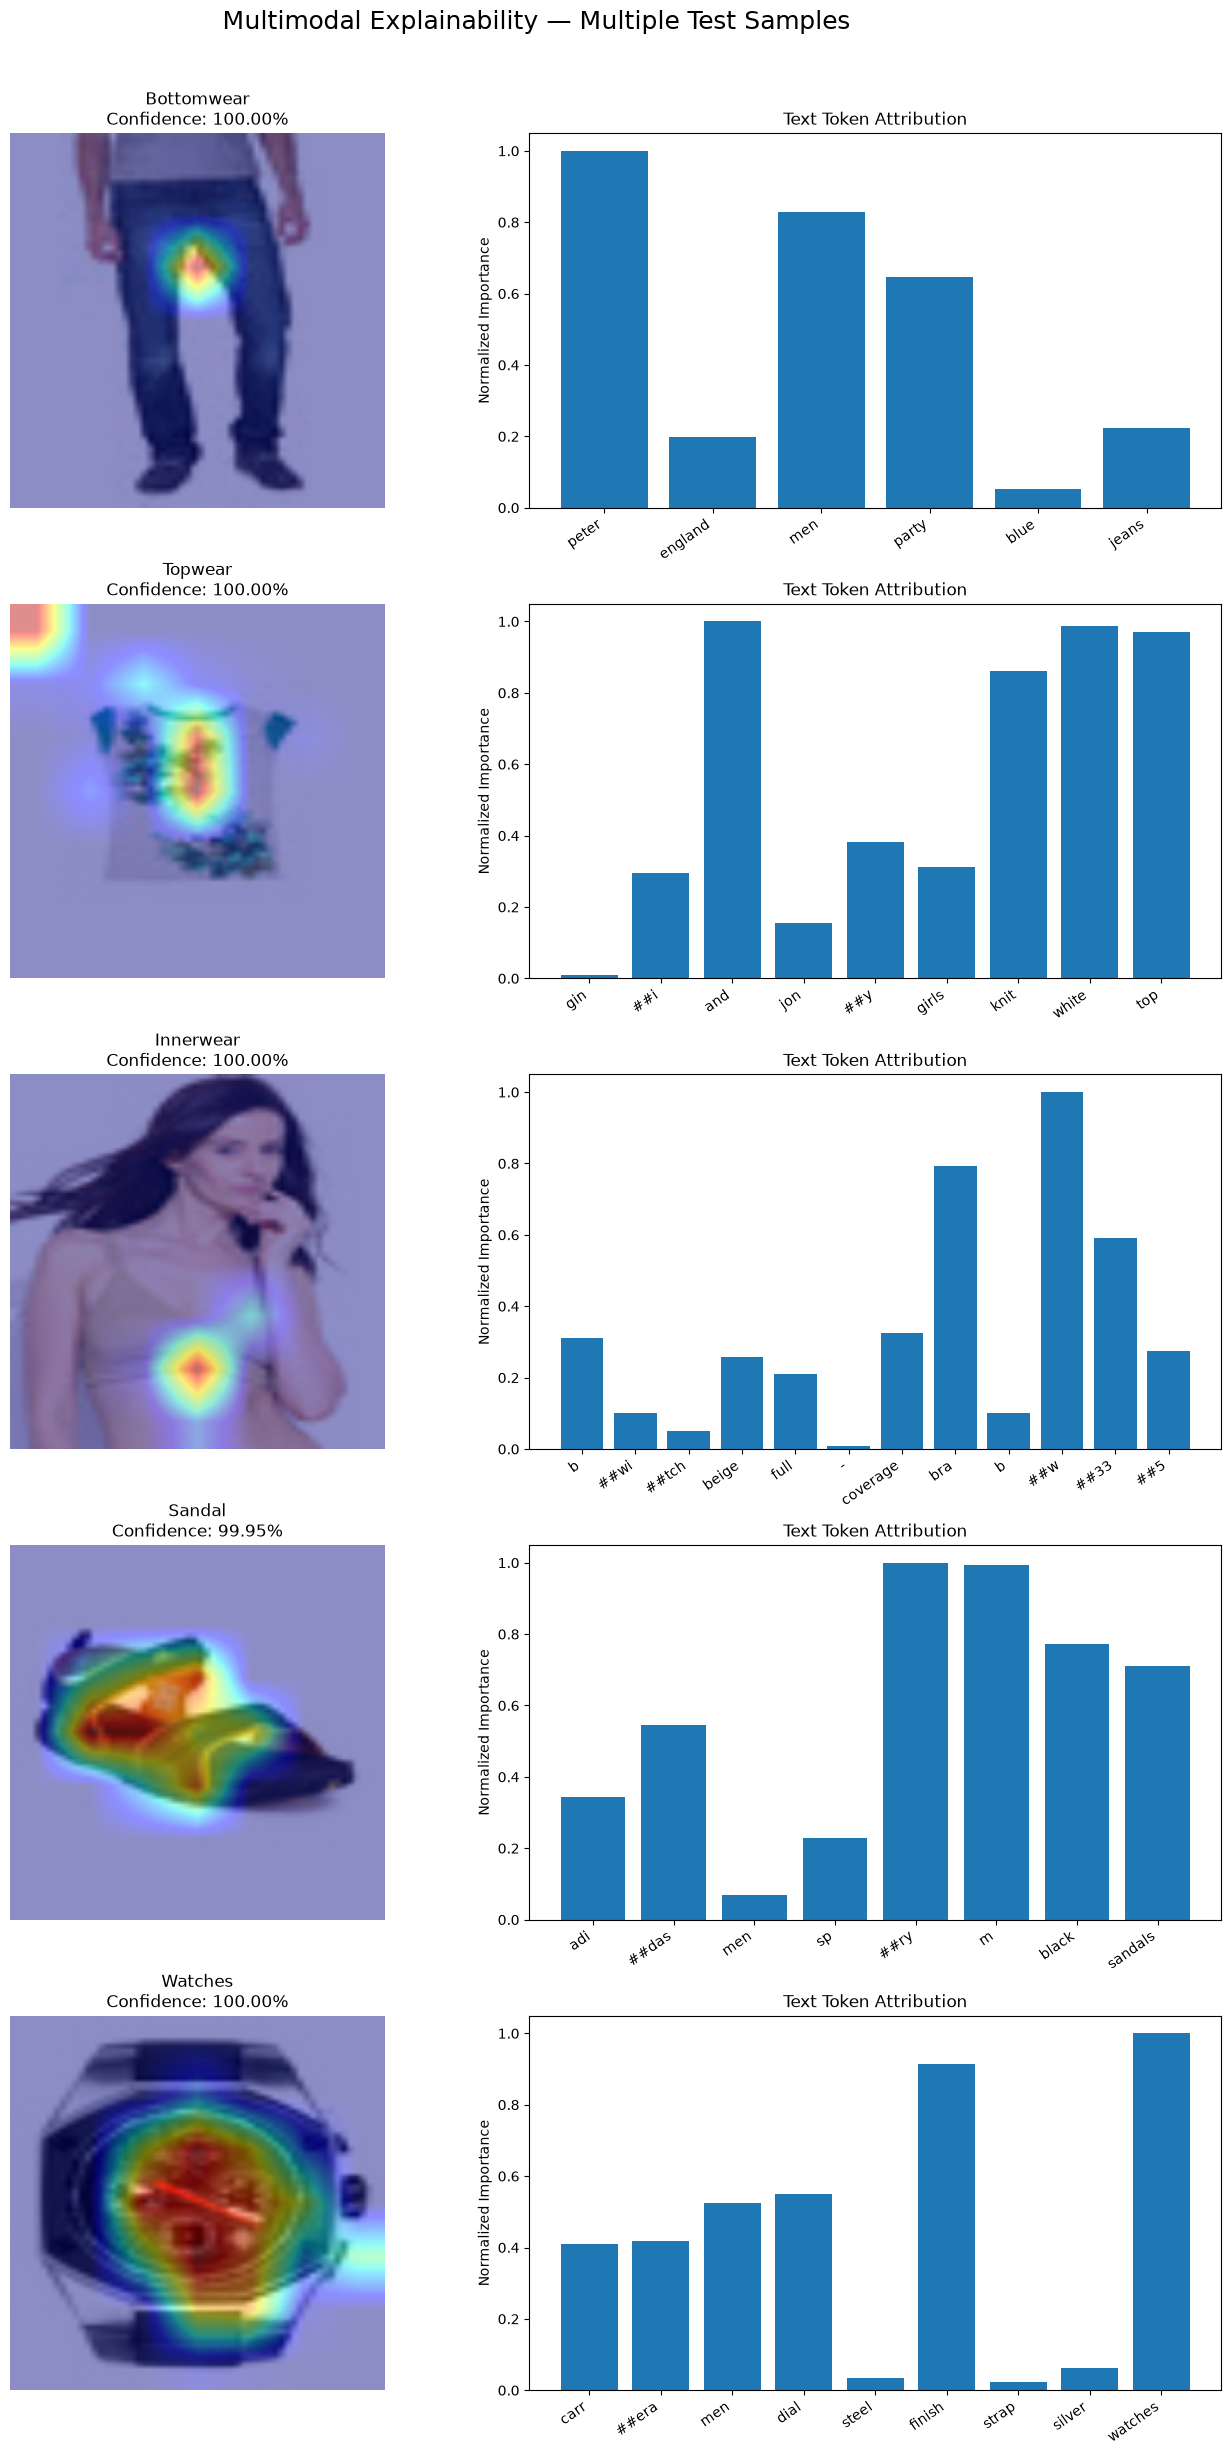

In [155]:
fig, axes = plt.subplots(
    len(explanations),
    2,
    figsize=(14, 5 * len(explanations))
)

for row, explanation in enumerate(
    explanations
):

    ax_image = axes[row, 0]

    sample = samples_for_explanation[row]

    image_tensor = (
        sample["batch"]["image"][
            sample["index"]
        ].cpu()
    )

    image_display = (
        image_tensor * std + mean
    ).clamp(0, 1)

    image_display = (
        image_display
        .permute(1, 2, 0)
        .numpy()
    )

    ax_image.imshow(image_display)

    ax_image.imshow(
        explanation["heatmap"],
        cmap="jet",
        alpha=0.45
    )

    ax_image.axis("off")

    ax_image.set_title(
        f"{explanation['predicted_class']}\n"
        f"Confidence: "
        f"{explanation['confidence']:.2%}"
    )

    ax_text = axes[row, 1]

    token_data = explanation[
        "token_importance"
    ]

    token_names = [
        token
        for token, _
        in token_data
    ]

    token_scores = [
        score
        for _, score
        in token_data
    ]

    ax_text.bar(
        range(len(token_names)),
        token_scores
    )

    ax_text.set_xticks(
        range(len(token_names))
    )

    ax_text.set_xticklabels(
        token_names,
        rotation=35,
        ha="right"
    )

    ax_text.set_ylim(0, 1.05)

    ax_text.set_ylabel(
        "Normalized Importance"
    )

    ax_text.set_title(
        "Text Token Attribution"
    )

plt.suptitle(
    "Multimodal Explainability — "
    "Multiple Test Samples",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [156]:
for param in optimized_multimodal_model.text_encoder.parameters():
    param.requires_grad = False

optimized_multimodal_model.eval()

print("✓ Model restored to inference configuration")

✓ Model restored to inference configuration


### Explainability & Model Interpretation

#### Objective

The goal of this phase was to provide interpretable signals for both
modalities of the multimodal product classification system.

The final model combines:

- ResNet-50 for product images
- DistilBERT for product names
- Multimodal fusion for the final prediction

#### Image Explainability

Grad-CAM was applied to the final convolutional layer of the fine-tuned
ResNet-50 Layer 4.

The Grad-CAM heatmap identifies spatial regions associated with the model's
score for the predicted class.

Examples across multiple test samples showed that the strongest activations
were generally concentrated around the relevant product regions, including:

- trousers for Bottomwear
- upper garments for Topwear
- the garment region for Innerwear
- the footwear for Sandal
- the watch body/face for Watches

Some samples also contained activation outside the primary product region.
Therefore, Grad-CAM is treated as an interpretation signal rather than a
pixel-perfect explanation.

#### Text Explainability

Gradient × embedding attribution was applied to DistilBERT's input token
embeddings.

For each token, the magnitude of the gradient multiplied by its embedding
was used as a local importance signal for the final multimodal prediction.

This revealed that different product names produced different attribution
patterns.

DistilBERT WordPiece tokenization can split words into subword tokens such
as `##...`. These tokens represent parts of the original word and are valid
model inputs.

#### Multimodal Explanation

The final explanation combines:

1. The predicted product category and confidence.
2. A Grad-CAM visualization for the image branch.
3. Token-level attribution for the text branch.

This provides complementary visual and textual interpretation signals for
the same multimodal prediction.

#### Important Interpretation Limitation

The explanations produced in this phase are attribution-based model
interpretation signals. They should not be treated as definitive causal
explanations of the model's reasoning.

Grad-CAM identifies influential spatial regions, while gradient × embedding
provides local sensitivity estimates for text tokens.

#### Explainability Validation

The explanation pipeline was tested on five correctly classified samples
from different product categories:

| Category | Prediction | Confidence |
|----------|------------|------------|
| Bottomwear | Bottomwear | 100.00% |
| Topwear | Topwear | 100.00% |
| Innerwear | Innerwear | 100.00% |
| Sandal | Sandal | 99.95% |
| Watches | Watches | 100.00% |

The results demonstrate that the multimodal system can provide both visual
and textual attribution signals alongside its product-category prediction.

71. Final Model State

In [158]:
for param in optimized_multimodal_model.parameters():
    param.requires_grad = False

optimized_multimodal_model.eval()

trainable_params = sum(
    p.numel()
    for p in optimized_multimodal_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)
print(
    "Model mode:",
    "eval" if not optimized_multimodal_model.training else "train"
)

Trainable parameters: 0
Model mode: eval
